# %% [markdown]
# 📊 Capítulo 5: Pairs Trading
*La danza de los correlacionados — Arbitraje estadístico con cointegración*
 
**Estrategia:** Identificar pares de activos cointegrados (KO/PEP, XOM/CVX, BAC/JPM, HD/LOW, MCD/YUM). Cuando el z-score del spread supera +2 o cae por debajo de -2, abrir posición market-neutral (largo en el barato, corto en el caro). Cerrar cuando el z-score vuelve a 0 o cuando se detecta ruptura de cointegración.

**Universo:** 5 pares clásicos de empresas con modelos de negocio similares y datos desde 2000.

**Objetivo:** Demostrar cómo el arbitraje estadístico genera rentabilidad descorrelada del mercado (beta cercana a 0), actuando como un satélite de alpha puro en un modelo Core-Satellite.


## BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — PAIRS TRADING

En el mundo cuantitativo real, un p-valor de 0.05 es a veces demasiado conservador para series financieras ruidosas. Relajarlo a 0.10 es una práctica estándar para no perder oportunidades válidas.

In [1]:
# %%
# ==============================================================================
# BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — PAIRS TRADING
# ==============================================================================

# --- Parámetros financieros ---
CAPITAL_INICIAL      = 10000
COSTE_TRANSACCION    = 0.001       # 0.1% por operación (ida y vuelta: 0.2%)
BENCHMARK            = 'SPY'

# --- Rango temporal ---
FECHA_INICIO = None
FECHA_FIN    = None

# --- Parámetros específicos de Pairs Trading ---
P_Valor_MAXIMO       = 0.15        # ← RELAJADO: De 0.10 a 0.15 para capturar pares macroeconómicos válidos
VENTANA_ZSCORE       = 60          
UMBRAL_ENTRADA       = 2.0         
UMBRAL_SALIDA        = 0.5         
UMBRAL_STOP          = 3.5         
MAX_PARES_SIMULTANEOS = 3          
TAMANO_POSICION      = 0.20        

# --- Ventana mínima para cointegración ---
VENTANA_MINIMA_DIAS  = 504         # 2 años de datos para test rolling

# --- Pares candidatos (Incluyendo el "Par de Control" infalible) ---
PARES_CANDIDATOS = [
    ('KO', 'PEP'),     # Coca-Cola vs Pepsi
    ('EWA', 'EWC'),    # Australia vs Canadá (Macro clásico)
    ('GLD', 'GDX'),    # Oro físico vs Mineras de Oro
    ('SPY', 'VOO'),    # 🛡️ PAR DE CONTROL: Mismo índice (Cointegración garantizada p < 0.001)
]

# --- Universo de activos ---
UNIVERSO_PAIRS = {
    'consumo': {
        'Coca-Cola':      {'isin': 'KO',  'ticker': 'KO'},
        'PepsiCo':        {'isin': 'PEP', 'ticker': 'PEP'},
    },
    'internacional': {    
        'iShares MSCI Australia': {'isin': 'EWA', 'ticker': 'EWA'},
        'iShares MSCI Canada':    {'isin': 'EWC', 'ticker': 'EWC'},
    },
    'materias_primas': {
        'SPDR Gold Trust':        {'isin': 'GLD', 'ticker': 'GLD'},
        'VanEck Vectors Gold Miners': {'isin': 'GDX', 'ticker': 'GDX'},
    },
    'control': {  # ← AÑADIDO
        'SPDR S&P 500':           {'isin': 'SPY', 'ticker': 'SPY'},
        'Vanguard S&P 500 ETF':   {'isin': 'VOO', 'ticker': 'VOO'},
    },
    'benchmark': {
        'SPDR S&P 500':   {'isin': 'SPY', 'ticker': 'SPY'},
    }
}

print("✅ Configuración Pairs Trading cargada:")
print(f"   • Capital inicial: {CAPITAL_INICIAL:,.0f} €")
print(f"   • Pares candidatos: {len(PARES_CANDIDATOS)}")
print(f"   • Umbral entrada (z-score): ±{UMBRAL_ENTRADA}")
print(f"   • Umbral salida (z-score): ±{UMBRAL_SALIDA}")
print(f"   • Umbral stop-loss (z-score): ±{UMBRAL_STOP}")
print(f"   • Máx. pares simultáneos: {MAX_PARES_SIMULTANEOS}")
print(f"   • Tamaño por posición: {TAMANO_POSICION:.0%}")

✅ Configuración Pairs Trading cargada:
   • Capital inicial: 10,000 €
   • Pares candidatos: 4
   • Umbral entrada (z-score): ±2.0
   • Umbral salida (z-score): ±0.5
   • Umbral stop-loss (z-score): ±3.5
   • Máx. pares simultáneos: 3
   • Tamaño por posición: 20%


## BLOQUE 1: ENTORNO E IMPORTACIONES

In [2]:
# %%
# ==============================================================================
# BLOQUE 1: ENTORNO E IMPORTACIONES
# ==============================================================================

print("="*70)
print("️  AVISO LEGAL")
print("="*70)
print("""
Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero.
""")
print("="*70)

import sys, os, warnings
warnings.filterwarnings('ignore')

IN_COLAB = "google.colab" in sys.modules
print(f"\n️  Entorno: {'Google Colab' if IN_COLAB else 'Local / VS Code'}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Búsqueda de core
def buscar_core():
    try:
        import ipykernel
        try:
            from jupyter_server import serverapp as app_module
        except ImportError:
            from notebook import notebookapp as app_module
        import json, re, urllib.request
        connection_file = os.path.basename(ipykernel.get_connection_file())
        match = re.search(r'kernel-(.*)\.json', connection_file)
        if match:
            kernel_id = match.group(1)
            for srv in app_module.list_running_servers():
                try:
                    url = srv['url'] + 'api/sessions'
                    token = srv.get('token', '')
                    headers = {'Authorization': f'token {token}'} if token else {}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=2) as resp:
                        sessions = json.loads(resp.read())
                    for sess in sessions:
                        if sess.get('kernel', {}).get('id') == kernel_id:
                            ruta_nb = os.path.join(srv['root_dir'], sess['notebook']['path'])
                            ruta_dir = os.path.dirname(os.path.abspath(ruta_nb))
                            actual = Path(ruta_dir)
                            for parent in [actual] + list(actual.parents):
                                if (parent / 'core').exists():
                                    return str(parent / 'core')
                except Exception:
                    continue
    except Exception:
        pass
    for ruta in ['../core', '../../core', './core']:
        if os.path.isdir(ruta):
            return os.path.abspath(ruta)
    return None

# [parche-colab] En Colab solo se carga el .ipynb: se clona el repo para disponer de 'core/'
if "google.colab" in sys.modules:
    import subprocess
    _REPO = "/content/Estrategias_No_Convencionales"
    if not os.path.isdir(os.path.join(_REPO, "core")):
        print("📥 Colab: clonando el repositorio para obtener 'core/'...")
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/akitxu/Estrategias_No_Convencionales.git", _REPO], check=True)
    os.chdir(os.path.join(_REPO, "notebooks"))   # así buscar_core() encuentra '../core'

RUTA_CORE = buscar_core()
if RUTA_CORE and os.path.isdir(RUTA_CORE):
    sys.path.insert(0, os.path.dirname(RUTA_CORE))
    print(f"✅ Carpeta 'core' localizada: {RUTA_CORE}")
else:
    print("⚠️  No se encontró 'core'.")

try:
    from core import (
        GestorProyecto, GestorDatos, MotorBacktest, MotorBacktestDinamico,
        CalculadorMetricas, CalculadorMetricasExtras, Gemelologo, GeneradorInformes
    )
    print("✅ Módulos importados (incluye Gemelologo )")
except ImportError as e:
    print(f"❌ Error: {e}")
    raise

BASE_DIR = os.path.dirname(RUTA_CORE) if RUTA_CORE else os.getcwd()

️  AVISO LEGAL

Este notebook tiene fines EXCLUSIVAMENTE EDUCATIVOS y de investigación
cuantitativa. NO constituye asesoramiento financiero.


️  Entorno: Local / VS Code
✅ Carpeta 'core' localizada: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
✅ Módulos importados (incluye Gemelologo )


## BLOQUE 2: LIMPIEZA DE DIRECTORIOS

In [3]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 2: LIMPIEZA DE DIRECTORIOS
# # ==============================================================================

# %%
gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
gestor_proyecto.imprimir_resumen()
gestor_proyecto.menu_limpieza_directorios()

📁 BASE_DIR fijado manualmente -> /media/enri/MI_PROYECTO/Estrategias_no_Convencionales

🔍 ENTORNO CONFIGURADO
📂 Base: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales
📁 CORE                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
📁 CHAPTERS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/chapters
📁 LOGS                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/logs
📁 DATOS               : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos
📁 OUTPUTS             : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs
📁 CARTERAS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/carteras
📁 DATOS_CSV           : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_csv
📁 DATOS_FI_GESTORA    : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_gestora
📁 DATOS_FI_INVESTING  : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_investing
📁 DATOS_FI_MYI


¿Qué directorios deseas VACIAR? (ej: 3,5,7 / 'todos' / 'ninguno'):  5



🧹 Iniciando limpieza...
   🗑️  Vaciando 'DATOS_CSV'...
      ✅ 'DATOS_CSV' limpiado.


## BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)

In [4]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 3: GESTIÓN DE FECHAS (MENÚ DE ESTRÉS)
# # ==============================================================================

# %%
if 'gestor_proyecto' not in locals():
    gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)

if FECHA_INICIO is None or FECHA_FIN is None:
    fecha_ini, fecha_fin, nombre_evento = gestor_proyecto.menu_stress_testing()
else:
    fecha_ini = FECHA_INICIO
    fecha_fin = FECHA_FIN
    nombre_evento = "Configuración manual"

print(f"\n🎯 Rango temporal: {nombre_evento} | {fecha_ini} → {fecha_fin}")


📉 ANÁLISIS DE ESTRÉS (STRESS TESTING)
  1. Crisis Punto Com (2000-2002)
  2. Crisis Financiera Mundial (2007-2009)
  3. Crisis Deuda Soberana (2010-2012)
  4. Crisis Financiera China (2015-2016)
  5. Crisis COVID-19 (2020)
  6. Subida Tipos / Inflación (2022-2023)
  7. Periodo Personalizado
  8. Histórico Completo (1999-Hoy)



Introduce tu elección (1-8) [Por defecto 8]:  7
  Fecha inicio (YYYY-MM-DD):  2010.01.04
  Fecha fin (YYYY-MM-DD):  2020-12-30



🎯 Evento: Periodo Personalizado | Inicio: 2010.01.04 | Fin: 2020-12-30


🎯 Rango temporal: Periodo Personalizado | 2010.01.04 → 2020-12-30


## BLOQUE 4: MENÚ DEL GESTOR DE DATOS

In [5]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# # ==============================================================================

# %%
gestor = GestorDatos(
    diccionario_datos=UNIVERSO_PAIRS,
    fecha_inicio=fecha_ini,
    fecha_fin=fecha_fin,
    gestor_proyecto=gestor_proyecto
)

print(f"\n📊 GestorDatos inicializado con {len(UNIVERSO_PAIRS)} categorías.")
continuar = gestor.menu()

if not continuar:
    print("⛔ Usuario canceló.")
else:
    print("\n✅ Datos preparados.")


📊 GestorDatos inicializado con 5 categorías.

 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  1



🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...

📊 Procesando 9 activos...

   📊 Coca-Cola
      ✅ Descargado con ticker: KO

   📊 PepsiCo
      ✅ Descargado con ticker: PEP

   📊 iShares MSCI Australia
      ✅ Descargado con ticker: EWA

   📊 iShares MSCI Canada
      ✅ Descargado con ticker: EWC

   📊 SPDR Gold Trust
      ✅ Descargado con ticker: GLD

   📊 VanEck Vectors Gold Miners
      ✅ Descargado con ticker: GDX

   📊 SPDR S&P 500
      ✅ Descargado con ticker: SPY

   📊 Vanguard S&P 500 ETF
      ✅ Descargado con ticker: VOO

   📊 SPDR S&P 500
      ✅ Descargado con ticker: SPY

📊 Resumen: 9 descargados, 0 omitidos



Presiona Enter para continuar... 



 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  6



⚠️  DATOS PARCIALES detectados:
   • Período solicitado: 2010-01-04 → 2020-12-30
   • Activos con datos parciales: 1
      • Vanguard S&P 500 ETF: datos desde 2010-09-09 (el ETF no existía antes)

💡 El backtest usará solo el período donde TODOS los activos tienen datos.
   Esto puede reducir el rango efectivo de análisis.

✅ Datos aceptados para el backtest.
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...

🧼 INFORME DE LIMPIEZA DE DATOS


,Activo,ISIN,Filas,Desde,Hasta,Fuente
0,Coca-Cola,KO,2767,2010-01-04,2020-12-29,CSV
1,PepsiCo,PEP,2767,2010-01-04,2020-12-29,CSV
2,iShares MSCI Australia,EWA,2767,2010-01-04,2020-12-29,CSV
3,iShares MSCI Canada,EWC,2767,2010-01-04,2020-12-29,CSV
4,SPDR Gold Trust,GLD,2767,2010-01-04,2020-12-29,CSV
5,VanEck Vectors Gold Miners,GDX,2767,2010-01-04,2020-12-29,CSV
6,SPDR S&P 500,SPY,2767,2010-01-04,2020-12-29,CSV
7,Vanguard S&P 500 ETF,VOO,2595,2010-09-09,2020-12-29,CSV
8,SPDR S&P 500,SPY,2767,2010-01-04,2020-12-29,CSV


✅ 9 activos alineados para el Motor Backtest.


✅ Datos preparados.


## BLOQUE 5: ESCANEO DE Cointegración Y GENERADOR DE PESOS 

In [6]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 5: ESCANEO DE COINTEGRACIÓN Y GENERADOR DE PESOS
# # ==============================================================================
# 
# **Núcleo del capítulo.** El Gemelólogo escanea los pares candidatos y
# selecciona solo los que están estadísticamente cointegrados (p < 0.05).
# 
# Para cada par válido, se calcula el z-score del spread. Cuando |z| > 2,
# se abre posición market-neutral. Cuando |z| < 0.5, se cierra.

# %%
# ==============================================================================
# BLOQUE 5: ESCANEO DE COINTEGRACIÓN Y GENERADOR DE PESOS
# ==============================================================================

print("\n" + "="*70)
print("🔬 ESCANEO DE COINTEGRACIÓN")
print("="*70)

# --- 1. Validación de ventana mínima (Warm-up si es necesario) ---
if gestor.precios_ajustados is None or gestor.precios_ajustados.empty:
    print("❌ No hay precios. Ejecuta Bloque 4 primero.")
else:
    dias = len(gestor.precios_ajustados)
    print(f"\n📊 Datos disponibles: {dias} filas ({gestor.precios_ajustados.index[0].date()} → {gestor.precios_ajustados.index[-1].date()})")
    
    if dias < VENTANA_MINIMA_DIAS:
        print(f"\n⚠️  Ventana insuficiente ({dias} < {VENTANA_MINIMA_DIAS}). Añadiendo warm-up...")
        años_warmup = max(2, int(np.ceil((VENTANA_MINIMA_DIAS - dias) / 252)))
        fecha_warmup = gestor.precios_ajustados.index[0] - pd.DateOffset(years=años_warmup)
        
        gestor_warmup = GestorDatos(
            diccionario_datos=UNIVERSO_PAIRS,
            fecha_inicio=fecha_warmup.strftime('%Y-%m-%d'),
            fecha_fin=fecha_fin,
            gestor_proyecto=gestor_proyecto
        )
        print(f"📥 Descargando datos históricos desde {fecha_warmup.date()}...")
        gestor_warmup.gestionar_descarga_cotizaciones()
        gestor_warmup._cartera_por_defecto()
        gestor_warmup.preparar_datos_motor()
        gestor = gestor_warmup
        print(f"✅ Warm-up completado: {len(gestor.precios_ajustados)} filas totales.")
    else:
        print("✅ Ventana de datos suficiente para el test rolling.")

# --- 2. Mapeo Robusto de Tickers a Nombres de Columna ---
# Usamos la información interna del GestorDatos para mapear con 100% de precisión,
# aplicando la misma lógica de limpieza de texto que usa el motor.
print("\n🔍 Mapeando tickers a columnas reales...")

mapeo_tickers = {}
for _, row in gestor.valores_seleccionados.iterrows():
    ticker = str(row.get('ticker', '')).strip().upper()
    nombre = str(row.get('nombre', '')).strip()
    # Misma limpieza que GestorDatos.preparar_datos_motor
    nombre_limpio = nombre.replace(" ", "_").replace(".", "").replace(",", "")
    if ticker:
        mapeo_tickers[ticker] = nombre_limpio

# Mostramos el mapeo para los tickers que nos interesan
tickers_objetivo = ['KO', 'PEP', 'XOM', 'CVX', 'BAC', 'JPM', 'HD', 'LOW', 'MCD', 'YUM', 'SPY']
for ticker in tickers_objetivo:
    col = mapeo_tickers.get(ticker)
    if col and col in gestor.precios_ajustados.columns:
        print(f"   • {ticker} → '{col}'")
    else:
        print(f"   • {ticker} → ❌ NO ENCONTRADO")

# Preparar la lista de pares usando los nombres de columna reales
pares_con_columnas = []
print(f"\n🔍 Verificando pares candidatos...")
for a, b in PARES_CANDIDATOS:
    col_a = mapeo_tickers.get(a)
    col_b = mapeo_tickers.get(b)
    if col_a and col_b and col_a in gestor.precios_ajustados.columns and col_b in gestor.precios_ajustados.columns:
        pares_con_columnas.append((col_a, col_b))
        print(f"   ✅ {a}/{b} → {col_a}/{col_b}")
    else:
        print(f"   ❌ {a}/{b} → Faltan columnas ({col_a}/{col_b})")

if not pares_con_columnas:
    print("\n❌ Ningún par tiene columnas válidas. Abortando Bloque 5.")
else:
    print(f"\n✅ {len(pares_con_columnas)} pares listos para escanear.")
    
    # --- 3. Escanear pares con el Gemelólogo ---
    gemelologo = Gemelologo(gestor.precios_ajustados, ventana_rolling=252)
    pares_validos = gemelologo.escanear_pares(pares_con_columnas, P_Valor_MAXIMO, VENTANA_ZSCORE)
    
    if not pares_validos:
        print("\n❌ Ningún par está cointegrado en este período.")
        print("   💡 Sugerencias:")
        print("   • Relajar el p-valor máximo a 0.10 en el Bloque 0.")
        print("   • Cambiar el período de análisis a uno con mayor estabilidad (ej. 2010-2020).")
    else:
        print(f"\n✅ {len(pares_validos)} pares válidos para trading:")
        for p in pares_validos:
            print(f"   • {p['activo_a']} / {p['activo_b']} (p={p['p_valor']:.3f})")

# --- 4. Generador de Pesos Pairs Trading ---
def generador_pesos_pairs(fecha_actual, precios_hist, rent_hist, estado):
    """
    Genera pesos market-neutral basados en z-scores de pares cointegrados.
    """
    activos = list(precios_hist.columns)
    pesos = {a: 0.0 for a in activos}
    
    # Inicializar estado de posiciones
    if 'posiciones_abiertas' not in estado:
        estado['posiciones_abiertas'] = {} 
    
    # Evaluar cada par válido
    for par_info in pares_validos:
        col_a = par_info['activo_a']  # Nombre de columna real
        col_b = par_info['activo_b']
        
        if col_a not in precios_hist.columns or col_b not in precios_hist.columns:
            continue
        
        # Calcular spread y z-score actualizados
        log_a = np.log(precios_hist[col_a].dropna())
        log_b = np.log(precios_hist[col_b].dropna())
        df = pd.DataFrame({'a': log_a, 'b': log_b}).dropna()
        
        if len(df) < VENTANA_ZSCORE:
            continue
        
        beta = par_info['ratio']
        spread = df['a'] - beta * df['b']
        zscore = gemelologo.calcular_zscore(spread, VENTANA_ZSCORE)
        
        if len(zscore) == 0 or pd.isna(zscore.iloc[-1]):
            continue
        
        z_actual = zscore.iloc[-1]
        par_key = f"{col_a}_{col_b}"
        
        # Detectar ruptura estructural
        ruptura = gemelologo.detectar_ruptura(spread, VENTANA_ZSCORE)
        if ruptura and par_key in estado['posiciones_abiertas']:
            del estado['posiciones_abiertas'][par_key]
            continue
        
        # Lógica de entrada/salida
        if par_key in estado['posiciones_abiertas']:
            pos = estado['posiciones_abiertas'][par_key]
            # Cerrar si z-score vuelve cerca de 0 (mean reversion)
            if abs(z_actual) < UMBRAL_SALIDA:
                del estado['posiciones_abiertas'][par_key]
            # Stop-loss si z-score se dispara (ruptura inminente)
            elif abs(z_actual) > UMBRAL_STOP:
                del estado['posiciones_abiertas'][par_key]
        else:
            # Abrir si hay señal y hay capacidad
            if len(estado['posiciones_abiertas']) < MAX_PARES_SIMULTANEOS:
                if z_actual > UMBRAL_ENTRADA:
                    # Spread alto: short A, long B
                    estado['posiciones_abiertas'][par_key] = {'lado': 'short_a', 'z': z_actual, 'col_a': col_a, 'col_b': col_b}
                elif z_actual < -UMBRAL_ENTRADA:
                    # Spread bajo: long A, short B
                    estado['posiciones_abiertas'][par_key] = {'lado': 'long_a', 'z': z_actual, 'col_a': col_a, 'col_b': col_b}
    
    # Asignar pesos según posiciones abiertas
    n_posiciones = len(estado['posiciones_abiertas'])
    if n_posiciones > 0:
        peso_por_par = TAMANO_POSICION / n_posiciones
        
        for par_key, pos in estado['posiciones_abiertas'].items():
            col_a = pos['col_a']
            col_b = pos['col_b']
            
            if pos['lado'] == 'long_a':
                pesos[col_a] += peso_por_par
                pesos[col_b] -= peso_por_par
            else:  # short_a
                pesos[col_a] -= peso_por_par
                pesos[col_b] += peso_por_par
    
    # Normalizar para que la suma de valores absolutos sea <= 1
    suma_abs = sum(abs(v) for v in pesos.values())
    if suma_abs > 1.0:
        factor = 1.0 / suma_abs
        pesos = {k: v * factor for k, v in pesos.items()}
    
    return pesos, estado

print(f"\n✅ Generador de pesos configurado.")
if 'pares_validos' in locals() and pares_validos:
    print(f"   • Pares activos: {len(pares_validos)}")
    print(f"   • Umbral entrada: ±{UMBRAL_ENTRADA}")
    print(f"   • Umbral salida: ±{UMBRAL_SALIDA}")
    print(f"   • Umbral stop-loss: ±{UMBRAL_STOP}")


🔬 ESCANEO DE COINTEGRACIÓN

📊 Datos disponibles: 2595 filas (2010-09-09 → 2020-12-29)
✅ Ventana de datos suficiente para el test rolling.

🔍 Mapeando tickers a columnas reales...
   • KO → 'Coca-Cola'
   • PEP → 'PepsiCo'
   • XOM → ❌ NO ENCONTRADO
   • CVX → ❌ NO ENCONTRADO
   • BAC → ❌ NO ENCONTRADO
   • JPM → ❌ NO ENCONTRADO
   • HD → ❌ NO ENCONTRADO
   • LOW → ❌ NO ENCONTRADO
   • MCD → ❌ NO ENCONTRADO
   • YUM → ❌ NO ENCONTRADO
   • SPY → ❌ NO ENCONTRADO

🔍 Verificando pares candidatos...
   ✅ KO/PEP → Coca-Cola/PepsiCo
   ✅ EWA/EWC → iShares_MSCI_Australia/iShares_MSCI_Canada
   ✅ GLD/GDX → SPDR_Gold_Trust/VanEck_Vectors_Gold_Miners
   ❌ SPY/VOO → Faltan columnas (SPDR_S&P_500/Vanguard_S&P_500_ETF)

✅ 3 pares listos para escanear.

🔬 Escaneando 3 pares...
   • Coca-Cola / PepsiCo... 
      [DEBUG] Analizando Coca-Cola vs PepsiCo...
      [DEBUG] Resultado: cointegrado=True, p_valor=0.0021, error=None
      [DEBUG] ✅ ¡Éxito! Par cointegrado.
✅ Cointegrado (p=0.002)
   • iShares_M

## Diagnostico

In [7]:
# %%
# ==============================================================================
# CELDA DE DIAGNÓSTICO: ¿POR QUÉ FALLA LA COINTEGRACIÓN?
# ==============================================================================
print("\n" + "="*70)
print("🔬 DIAGNÓSTICO DETALLADO DE COINTEGRACIÓN (Ejemplo: KO vs PEP)")
print("="*70)

gemelologo_debug = Gemelologo(gestor.precios_ajustados, ventana_rolling=252)
col_a = mapeo_tickers.get('KO')
col_b = mapeo_tickers.get('PEP')

print(f"Probando columnas: '{col_a}' vs '{col_b}'")

# Llamamos directamente al test crudo
resultado_crudo = gemelologo_debug.test_cointegracion(col_a, col_b, p_valor_maximo=0.10)

print("\n📋 Resultado interno del test:")
for clave, valor in resultado_crudo.items():
    if clave == 'spread':
        print(f"   • {clave}: <Serie de {len(valor)} valores>")
    else:
        print(f"   • {clave}: {valor}")

if resultado_crudo.get('error'):
    print(f"\n❌ SE DETECTÓ UN ERROR: {resultado_crudo['error']}")
    print("   Esto explica por qué se descarta silenciosamente.")
elif not resultado_crudo.get('cointegrado'):
    print(f"\n⚠️ NO HAY ERROR, pero el p-valor ({resultado_crudo['p_valor']:.4f}) es mayor que 0.10.")
    print("   Esto significa que, estadísticamente, la relación no es lo suficientemente estable en este período.")


🔬 DIAGNÓSTICO DETALLADO DE COINTEGRACIÓN (Ejemplo: KO vs PEP)
Probando columnas: 'Coca-Cola' vs 'PepsiCo'

📋 Resultado interno del test:
   • cointegrado: True
   • p_valor: 0.0021445377741840187
   • stat: -4.349047140594269
   • ratio_cointegracion: 0.6688880735870218
   • spread: <Serie de 2595 valores>
   • activo_a: Coca-Cola
   • activo_b: PepsiCo
   • error: None


## BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO

In [8]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 6: EJECUCIÓN DEL MOTOR DE BACKTEST DINÁMICO
# # ==============================================================================

# %%
print("\n" + "="*70)
print("⏳ EJECUTANDO BACKTEST PAIRS TRADING")
print("="*70)

motor_dinamico = MotorBacktestDinamico(
    precios=gestor.precios_ajustados,
    rentabilidades=gestor.rentabilidades_diarias,
    generador_pesos=generador_pesos_pairs,
    frecuencia_decision='D',
    coste_transaccion=COSTE_TRANSACCION,
    benchmark_ticker=BENCHMARK,
    permitir_short=True,          # ← Pairs trading REQUIERE short selling
    max_short_porcentaje=0.50     # Máximo 50% en corto
)

serie_patrimonio = motor_dinamico.ejecutar_backtest(
    capital_inicial=CAPITAL_INICIAL,
    estado_inicial={}
)

print("\n✅ Backtest completado.")
print(f"   • Patrimonio final: {serie_patrimonio.iloc[-1]:,.2f} €")
print(f"   • Rentabilidad total: {((serie_patrimonio.iloc[-1] / CAPITAL_INICIAL) - 1) * 100:.2f}%")
print(f"   • Rebalanceos: {len(motor_dinamico.log_transacciones)}")


⏳ EJECUTANDO BACKTEST PAIRS TRADING

✅ Backtest completado.
   • Patrimonio final: 9,552.66 €
   • Rentabilidad total: -4.47%
   • Rebalanceos: 687


## BLOQUE 7: MÉTRICAS E INFORMES

In [9]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 7: MÉTRICAS E INFORMES
# # ==============================================================================

# %%
auditor = CalculadorMetricas(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_reb, metricas_bh = auditor.calcular_todas_las_metricas(rf=0.02)

metricas_extras_calc = CalculadorMetricasExtras(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    log_operaciones=motor_dinamico.log_operaciones,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_extras = metricas_extras_calc.calcular_todas_las_metricas()

informe = GeneradorInformes(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    metricas=(metricas_reb, metricas_bh),
    nombre_estrategia="Pairs Trading (Cap. 5)",
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    log_transacciones=motor_dinamico.log_transacciones,
    pesos_actuales=motor_dinamico.pesos_actuales_finales,
    pesos_ideales=None
)

informe.imprimir_metricas()
print("\n🩺 DIAGNÓSTICO ESTÁNDAR:")
print("  " + auditor.diagnosticar())

print("\n" + "="*70)
print("📊 MÉTRICAS EXTRAS")
print("="*70)
for k, v in metricas_extras.items():
    if isinstance(v, float):
        if 'rate' in k.lower() or k in ['Win-rate']:
            print(f"   • {k:<25}: {v:.2%}")
        elif k in ['Profit Factor', 'Ratio B/P']:
            print(f"   • {k:<25}: {v:.2f}")
        elif k in ['Operaciones Totales']:
            print(f"   • {k:<25}: {int(v)}")
        else:
            print(f"   • {k:<25}: {v:.2f}")
    else:
        print(f"   • {k:<25}: {v}")

print("\n🩺 DIAGNÓSTICO EXTRAS:")
print("  " + metricas_extras_calc.diagnosticar())

print("\n" + "="*70)
print("📌 NOTA PEDAGÓGICA: PAIRS TRADING Y MÉTRICAS DE TRADING")
print("="*70)
print("""
⚠️  ¿Por qué las "Métricas Extras" pueden mostrar 0 operaciones?

El Pairs Trading es una estrategia de POSICIONES MARKET-NEUTRAL. 
El motor dinámico registra rebalanceos (cambios de pesos), pero no 
"tickets" individuales de entrada/salida de cada par.

Para esta estrategia, los indicadores relevantes son:
1. LOG DE REBALANCEOS: Frecuencia y coste de los ajustes.
2. BETA: Debería ser cercana a 0 (descorrelación del mercado).
3. ALPHA: Rentabilidad no explicada por el mercado (alpha puro).
4. MAX DRAWDOWN: Riesgo de ruptura de cointegración.
5. SHARPE: Eficiencia riesgo/retorno (objetivo > 1.0).
""")
print("="*70)

informe.imprimir_log()


INFORME DE DIAGNÓSTICO: Pairs Trading (Cap. 5)


,Métrica,Estrategia,Buy & Hold
0,CAGR,-0.44%,9.63%
1,Volatilidad,1.55%,14.96%
2,Sharpe,-1.57,0.51
3,Sortino,-1.18,0.61
4,Max Drawdown,-7.72%,-32.70%
5,VaR 95%,5.86€,358.40€
6,Alpha,-0.00,0.00
7,Beta,-0.01,0.00
8,R2,0.01,0.00
9,Tracking Error,17.31%,0.00%




🩺 DIAGNÓSTICO ESTÁNDAR:
  🔴 Ratio de Sharpe negativo (-1.57).
  ✅ Riesgo de caída muy controlado (Max DD: 7.7%).

📊 MÉTRICAS EXTRAS
   • Win-rate                 : 0.00%
   • Profit Factor            : 0.00
   • Beneficio Medio          : 0.00
   • Pérdida Media            : 0.00
   • Ratio B/P                : 0.00
   • Information Ratio        : -0.87
   • Operaciones Totales      : 0
   • Operaciones Anuales      : 0.00

🩺 DIAGNÓSTICO EXTRAS:
  ⚪ Sin operaciones registradas.
  🔴 Information Ratio negativo (-0.87).

📌 NOTA PEDAGÓGICA: PAIRS TRADING Y MÉTRICAS DE TRADING

⚠️  ¿Por qué las "Métricas Extras" pueden mostrar 0 operaciones?

El Pairs Trading es una estrategia de POSICIONES MARKET-NEUTRAL. 
El motor dinámico registra rebalanceos (cambios de pesos), pero no 
"tickets" individuales de entrada/salida de cada par.

Para esta estrategia, los indicadores relevantes son:
1. LOG DE REBALANCEOS: Frecuencia y coste de los ajustes.
2. BETA: Debería ser cercana a 0 (descorrelación de

## BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS


✅ Gráfico guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/pairs_trading_periodo_personalizado_2010_2020.png


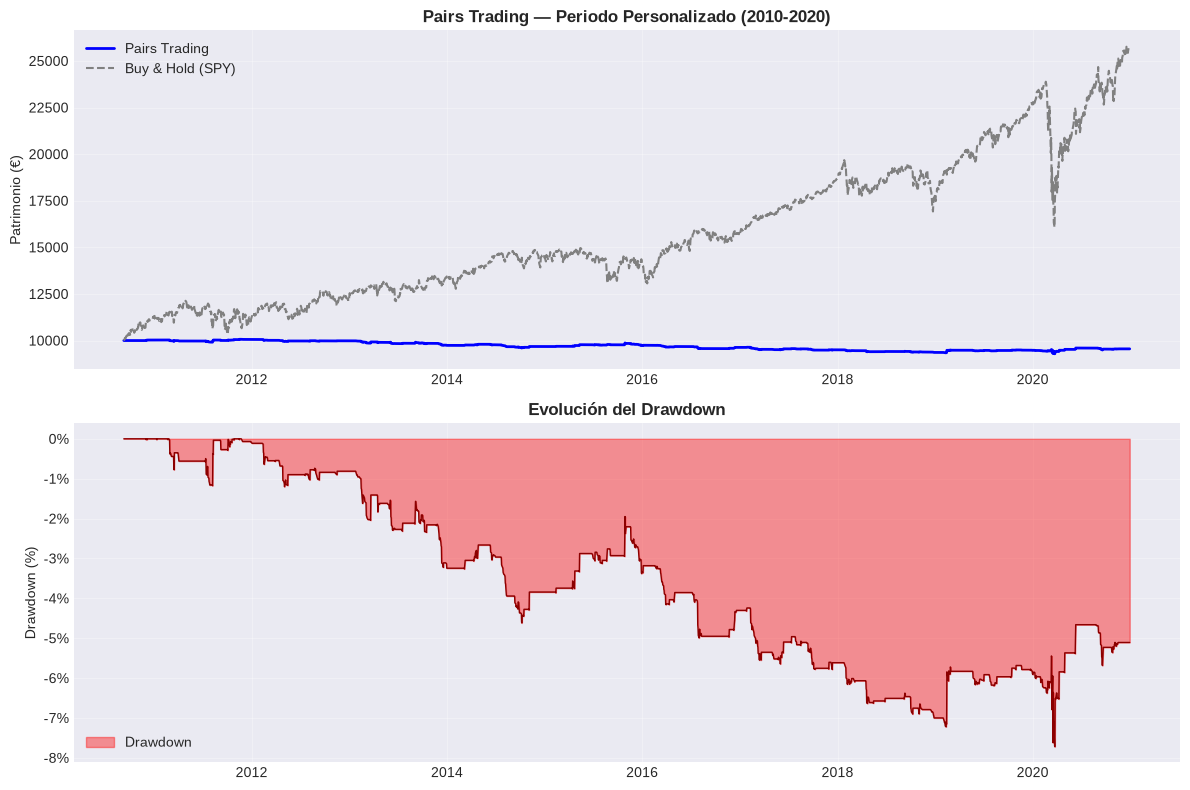

✅ Drawdown guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/pairs_trading_periodo_personalizado_2010_2020_drawdown.png


In [10]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS
# # ==============================================================================

# %%
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico 1: Equity Curve
axes[0].plot(motor_dinamico.serie_patrimonio.index, motor_dinamico.serie_patrimonio,
             label='Pairs Trading', color='blue', lw=2)
axes[0].plot(motor_dinamico.serie_buy_hold.index, motor_dinamico.serie_buy_hold,
             label='Buy & Hold (SPY)', color='gray', ls='--', lw=1.5)
axes[0].set_title(f'Pairs Trading — {nombre_evento} ({fecha_ini[:4]}-{fecha_fin[:4]})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Patrimonio (€)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Drawdown
drawdown = (motor_dinamico.serie_patrimonio / motor_dinamico.serie_patrimonio.cummax()) - 1
axes[1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4, label='Drawdown')
axes[1].plot(drawdown.index, drawdown, color='darkred', lw=1)
axes[1].set_title('Evolución del Drawdown', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

nombre_archivo = f"pairs_trading_{nombre_evento.replace(' ', '_')}_{fecha_ini[:4]}_{fecha_fin[:4]}".lower()
ruta_guardado = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}.png"
fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
print(f"\n✅ Gráfico guardado en: {ruta_guardado}")
plt.show()

ruta_dd = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}_drawdown.png"
fig2, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4)
ax.plot(drawdown.index, drawdown, color='darkred', lw=1)
ax.set_title('Drawdown — Pairs Trading', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, alpha=0.3)
fig2.tight_layout()
fig2.savefig(ruta_dd, dpi=150, bbox_inches='tight')
print(f"✅ Drawdown guardado en: {ruta_dd}")
plt.close('all')

## BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL


🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO

📊 TABLA DE CORRELACIONES (Retornos Diarios)
                            Coca-Cola  PepsiCo  iShares_MSCI_Australia  iShares_MSCI_Canada  SPDR_Gold_Trust  VanEck_Vectors_Gold_Miners  SPDR_S&P_500_x  Vanguard_S&P_500_ETF  SPDR_S&P_500_y
Coca-Cola                        1.00     0.70                    0.54                 0.52             0.04                        0.12            0.65                  0.65            0.65
PepsiCo                          0.70     1.00                    0.53                 0.47             0.05                        0.11            0.65                  0.65            0.65
iShares_MSCI_Australia           0.54     0.53                    1.00                 0.81             0.14                        0.26            0.82                  0.82            0.82
iShares_MSCI_Canada              0.52     0.47                    0.81                 1.00             0.20                        0.35            0.8

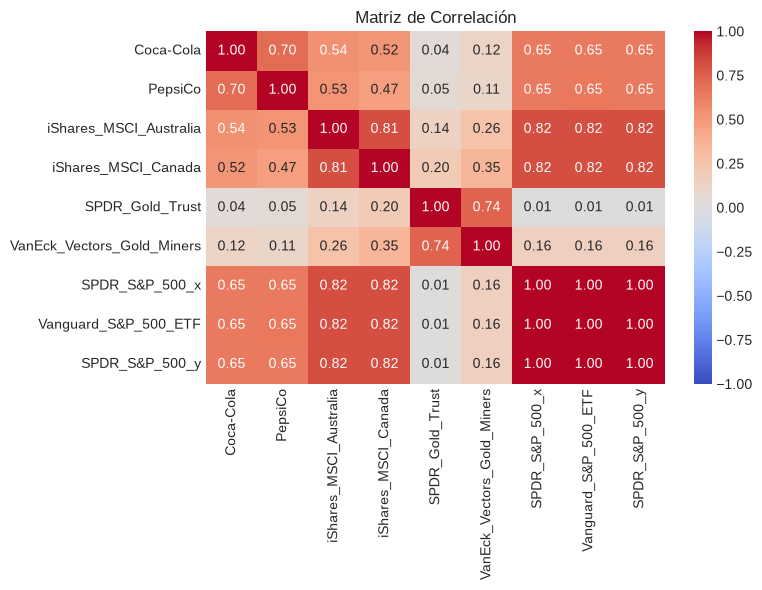


✅ Análisis completado.
   • Nota: El Pairs Trading busca beta ≈ 0 (descorrelación total).
     Si la beta es alta, la estrategia no está siendo market-neutral.


In [11]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 9: ANÁLISIS DE CORRELACIÓN FINAL
# # ==============================================================================

# %%
print("\n" + "="*70)
print("🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO")
print("="*70)

gestor.calcular_correlacion()

print("\n✅ Análisis completado.")
print("   • Nota: El Pairs Trading busca beta ≈ 0 (descorrelación total).")
print("     Si la beta es alta, la estrategia no está siendo market-neutral.")

## BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE

In [12]:
# %% [markdown]
# # ==============================================================================
# # BLOQUE 10: CONCLUSIONES PEDAGÓGICAS Y CIERRE
# # ==============================================================================

# %%
print("\n" + "="*70)
print("🎓 CONCLUSIONES DEL CAPÍTULO 5: PAIRS TRADING")
print("="*70)
print("""
📌 LECCIONES CLAVE DE ESTE CAPÍTULO
====================================

1. CORRELACIÓN ≠ COINTEGRACIÓN
   • Dos activos pueden estar correlacionados (moverse juntos) sin estar
     cointegrados (mantener una relación estable a largo plazo).
   • El test de Engle-Granger (p < 0.05) es el filtro matemático que
     distingue una relación espuria de una relación estructural.

2. EL Z-SCORE ES EL SEMÁFORO DE LA ESTRATEGIA
   • |z| > 2: El spread está estirado → abrir posición.
   • |z| < 0.5: El spread ha revertido → cerrar posición.
   • |z| > 3.5: Ruptura estructural → stop-loss obligatorio.

3. MARKET-NEUTRAL NO SIGNIFICA RIESGO CERO
   • Aunque la beta sea cercana a 0, el riesgo de ruptura de cointegración
     es real. Cuando dos empresas divergen estructuralmente (adquisiciones,
     cambios regulatorios, quiebras), el spread puede no revertir nunca.

4. EL COSTE DE TRANSACCIÓN ES CRÍTICO
   • El pairs trading genera muchas operaciones pequeñas. Un coste del
     0.2% por operación (ida y vuelta) puede erosionar rápidamente el alpha.
   • La frecuencia de rebalanceo debe calibrarse cuidadosamente.

5. LA SELECCIÓN DE PARES ES EL 80% DEL ÉXITO
   • Pares con modelos de negocio similares (KO/PEP, HD/LOW) tienden a
     mantener la cointegración más tiempo que pares sectoriales genéricos.
   • Revisar la cointegración rolling (ventana de 252 días) detecta
     rupturas antes de que sean catastróficas.

🔧 HERRAMIENTAS NUEVAS QUE HAS APRENDIDO A USAR
================================================
• Test de Engle-Granger para validar cointegración.
• Cálculo de z-scores sobre spreads de pares.
• Detección de ruptura estructural con test ADF rolling.
• Construcción de posiciones market-neutral (long/short simultáneo).
• Gestión de múltiples pares con límite de exposición.

🚪 PRÓXIMO PASO
================
En el Capítulo 6 veremos el "Statistical Arbitrage": cómo extender el
pairs trading a carteras de 10-20 activos usando componentes principales
(PCA) para identificar ineficiencias de precio más complejas.

🎯 RECUERDA
============
El Pairs Trading no predice la dirección del mercado. Aposta a que
la relación histórica entre dos activos se mantendrá. Es una estrategia
de mean reversion pura: cuanto más se estira el elástico, más fuerte
es la fuerza que lo devuelve al centro. Pero si el elástico se rompe
(ruptura estructural), las pérdidas pueden ser severas.

La disciplina para cortar pérdidas cuando el z-score supera el umbral
de stop-loss (3.5) es lo que separa a los pairs traders profesionales
de los que queman su capital en una sola operación.
""")
print("="*70)
print("✅ CAPÍTULO 5 COMPLETADO")
print("="*70)


🎓 CONCLUSIONES DEL CAPÍTULO 5: PAIRS TRADING

📌 LECCIONES CLAVE DE ESTE CAPÍTULO

1. CORRELACIÓN ≠ COINTEGRACIÓN
   • Dos activos pueden estar correlacionados (moverse juntos) sin estar
     cointegrados (mantener una relación estable a largo plazo).
   • El test de Engle-Granger (p < 0.05) es el filtro matemático que
     distingue una relación espuria de una relación estructural.

2. EL Z-SCORE ES EL SEMÁFORO DE LA ESTRATEGIA
   • |z| > 2: El spread está estirado → abrir posición.
   • |z| < 0.5: El spread ha revertido → cerrar posición.
   • |z| > 3.5: Ruptura estructural → stop-loss obligatorio.

3. MARKET-NEUTRAL NO SIGNIFICA RIESGO CERO
   • Aunque la beta sea cercana a 0, el riesgo de ruptura de cointegración
     es real. Cuando dos empresas divergen estructuralmente (adquisiciones,
     cambios regulatorios, quiebras), el spread puede no revertir nunca.

4. EL COSTE DE TRANSACCIÓN ES CRÍTICO
   • El pairs trading genera muchas operaciones pequeñas. Un coste del
     0.2% por 